In [ ]:
import pandas as pd

file_path = '/content/PPMI_Curated_Data_Cut_Public_20260511 (1).xlsx'
df_ppmi = pd.read_excel(file_path)
display(df_ppmi.head())

,SITE,PATNO,COHORT,subgroup,enroll_phase,enroll_source,analytic_subgroup,HIQ_RBD,study_status,Death_Status,...,MIA_PUTAMEN_BILAT,MIA_STRIATUM_L,MIA_STRIATUM_R,MIA_STRIATUM_BILAT,Stage_partial_UPDRS1,Stage_subpark,Stage_PDTreat,Stage_S,Stage_D,Stage_G
0,19,100001,1,Sporadic PD,2,NaN,NaN,NaN,Active,0.0,...,0.62,0.84,0.50,0.67,7.0,22.0,0.0,1.0,1.0,NaN
1,19,100001,1,Sporadic PD,2,NaN,NaN,NaN,Active,0.0,...,0.58,0.74,0.47,0.61,5.0,29.0,0.0,1.0,1.0,NaN
2,19,100001,1,Sporadic PD,2,NaN,NaN,NaN,Active,0.0,...,0.51,0.68,0.42,0.55,5.0,34.0,0.0,1.0,1.0,NaN
3,19,100001,1,Sporadic PD,2,NaN,NaN,NaN,Active,0.0,...,NaN,NaN,NaN,NaN,4.0,42.0,0.0,1.0,1.0,NaN
4,19,100001,1,Sporadic PD,2,NaN,NaN,NaN,Active,0.0,...,0.53,0.73,0.37,0.56,5.0,42.0,0.0,1.0,1.0,NaN


In [ ]:
import pandas as pd

# Define your target file path
file_path = '/content/PPMI_Curated_Data_Cut_Public_20260511 (1).xlsx'

# Read the curated dataset
df_ppmi = pd.read_excel(file_path)

# Organize all the features you requested into a single list
target_attributes = [
    # Baseline Demographics
    'age', 'SEX', 'EDUCYRS', 'BMI', 'race', 'handed',
    # Family History
    'fampd', 'fampd_bin',
    # Disease History
    'agediag', 'ageonset', 'duration', 'duration_yrs', 'DOMSIDE',
    # Prodromal Symptoms
    'sym_tremor', 'sym_rigid', 'sym_brady', 'sym_posins', 'sym_other',
    # Smell Test
    'upsit', 'upsit_pctl', 'upsit_pctl15',
    # Cognitive Tests
    'moca', 'bjlot', 'clockdraw', 'hvlt_discrimination',
    'hvlt_immediaterecall', 'hvlt_retention', 'lexical', 'lns',
    'MODBNT', 'SDMTOTAL', 'TMT_A', 'TMT_B', 'VLTANIM',
    # Sleep Disorders
    'rem', 'ess',
    # Mood & Psychiatric
    'gds', 'stai', 'stai_state', 'stai_trait',
    # Autonomic Dysfunction
    'scopa', 'scopa_gi', 'scopa_ur', 'scopa_cv', 'scopa_therm', 'scopa_pm', 'scopa_sex',
    'orthostasis',
    # Motor Assessment
    'NP1COG', 'NP1HALL', 'NP1DPRS', 'NP1ANXS', 'NP1APAT', 'NP1DDS', 'NP1FATG',
    'updrs1_score', 'updrs2_score', 'updrs3_score', 'updrs4_score', 'updrs_totscore',
    # Functional Status
    'PDAQ27', 'MSEADLG', 'nqol_cogns', 'nqol_comms', 'nqol_lefs', 'nqol_uefs'
]

# Ensure we only slice columns that actually exist in your DataFrame
existing_columns = [col for col in target_attributes if col in df_ppmi.columns]

# Create a filtered DataFrame containing only your selected attributes
df_selected = df_ppmi[existing_columns]

# Calculate total missing values and their respective percentages
missing_count = df_selected.isnull().sum()
missing_percentage = (df_selected.isnull().sum() / len(df_selected)) * 100

# Combine into a clean summary table
missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percentage
})

# Display the summary sorted by highest missing percentage
display(missing_summary.sort_values(by='Percentage (%)', ascending=False))

,Missing Values,Percentage (%)
PDAQ27,15073,77.496144
updrs4_score,13290,68.329049
upsit_pctl,11778,60.555270
upsit,11778,60.555270
upsit_pctl15,11759,60.457584
...,...,...
fampd_bin,19,0.097686
fampd,19,0.097686
EDUCYRS,18,0.092545
SEX,0,0.000000


In [ ]:
# List of columns to remove (all >50% missing values from your report)
columns_to_drop = [
    'PDAQ27', 'updrs4_score', 'upsit_pctl', 'upsit_pctl15', # Kept 'upsit' deliberately
    'sym_rigid', 'sym_posins', 'sym_brady', 'sym_other',
    'ageonset', 'sym_tremor', 'DOMSIDE', 'duration_yrs', 'agediag', 'duration' , 'duration_yrs'
]

# Filter your list of features to keep only the ones below 50% missing (plus upsit)
final_features = [col for col in target_attributes if col not in columns_to_drop]

# Update your DataFrame to keep only these columns
X = df_ppmi[final_features].copy()

print(f"Remaining attributes for training: {final_features}")

Remaining attributes for training: ['age', 'SEX', 'EDUCYRS', 'BMI', 'race', 'handed', 'fampd', 'fampd_bin', 'upsit', 'moca', 'bjlot', 'clockdraw', 'hvlt_discrimination', 'hvlt_immediaterecall', 'hvlt_retention', 'lexical', 'lns', 'MODBNT', 'SDMTOTAL', 'TMT_A', 'TMT_B', 'VLTANIM', 'rem', 'ess', 'gds', 'stai', 'stai_state', 'stai_trait', 'scopa', 'scopa_gi', 'scopa_ur', 'scopa_cv', 'scopa_therm', 'scopa_pm', 'scopa_sex', 'orthostasis', 'NP1COG', 'NP1HALL', 'NP1DPRS', 'NP1ANXS', 'NP1APAT', 'NP1DDS', 'NP1FATG', 'updrs1_score', 'updrs2_score', 'updrs3_score', 'updrs_totscore', 'MSEADLG', 'nqol_cogns', 'nqol_comms', 'nqol_lefs', 'nqol_uefs']


In [ ]:
# 1. Drop columns with >50% missing values (keeping 'upsit')
columns_to_drop = [
    'PDAQ27', 'updrs4_score', 'upsit_pctl', 'upsit_pctl15',
    'sym_rigid', 'sym_posins', 'sym_brady', 'sym_other',
    'ageonset', 'sym_tremor', 'DOMSIDE', 'duration_yrs', 'agediag', 'duration'
]
final_features = [col for col in target_attributes if col not in columns_to_drop]

# 2. Extract features (X) while excluding PRIMDIAG from your inputs
X = df_ppmi[final_features].copy()
if 'PRIMDIAG' in X.columns:
    X = X.drop(columns=['PRIMDIAG'])

# 3. Create your binary target (y) predicting Parkinson's Disease (Code 'PD' or string name)
# (Check df_ppmi['PRIMDIAG'].value_counts() to confirm if your dataset uses codes or text)
y = df_ppmi['PRIMDIAG'].apply(lambda x: 1 if str(x).strip() in ["PD", "Idiopathic Parkinson's Disease"] else 0)

In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# 1. Separate features and target
columns_to_drop = [
    'PDAQ27', 'updrs4_score', 'upsit_pctl', 'upsit_pctl15',
    'sym_rigid', 'sym_posins', 'sym_brady', 'sym_other',
    'ageonset', 'sym_tremor', 'DOMSIDE', 'duration_yrs', 'agediag', 'duration'
]
final_features = [col for col in target_attributes if col not in columns_to_drop]

X = df_ppmi[final_features].copy()
if 'PRIMDIAG' in X.columns:
    X = X.drop(columns=['PRIMDIAG'])

# Map PRIMDIAG to a binary target (1 for Parkinson's Disease, 0 for others)
y = df_ppmi['PRIMDIAG'].apply(lambda x: 1 if str(x).strip() in ["PD", "Idiopathic Parkinson's Disease"] else 0)

# Ensure categorical types are preserved for XGBoost
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype.name == 'category':
        X[col] = X[col].astype('category')

# 2. Train and Evaluate using 4-Fold Cross Validation
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Initialize and train XGBoost
    model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        enable_categorical=True,
        tree_method='hist',
        random_state=42
    )
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    print(f"\n================ FOLD {fold} ================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


================ FOLD 1 ================
Confusion Matrix:
[[4863]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4863

    accuracy                           1.00      4863
   macro avg       1.00      1.00      1.00      4863
weighted avg       1.00      1.00      1.00      4863



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



================ FOLD 2 ================
Confusion Matrix:
[[4863]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4863

    accuracy                           1.00      4863
   macro avg       1.00      1.00      1.00      4863
weighted avg       1.00      1.00      1.00      4863



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



================ FOLD 3 ================
Confusion Matrix:
[[4862]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4862

    accuracy                           1.00      4862
   macro avg       1.00      1.00      1.00      4862
weighted avg       1.00      1.00      1.00      4862



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



================ FOLD 4 ================
Confusion Matrix:
[[4862]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4862

    accuracy                           1.00      4862
   macro avg       1.00      1.00      1.00      4862
weighted avg       1.00      1.00      1.00      4862



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
# Check how the labels are stored in PRIMDIAG
print(df_ppmi['PRIMDIAG'].value_counts(dropna=False))

PRIMDIAG
1.0     8794
17.0    5622
25.0    3931
97.0     288
23.0     247
7.0      193
NaN      135
24.0     101
11.0      44
5.0       40
15.0      17
9.0       13
2.0       10
12.0       5
14.0       4
18.0       2
4.0        2
10.0       1
16.0       1
Name: count, dtype: int64


In [ ]:
# Create your binary target (y): 1 if Parkinson's (code 1.0), 0 for others
y = df_ppmi['PRIMDIAG'].apply(lambda x: 1 if x == 1.0 else 0)

In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# 1. Separate features and target
columns_to_drop = [
    'PDAQ27', 'updrs4_score', 'upsit_pctl', 'upsit_pctl15',
    'sym_rigid', 'sym_posins', 'sym_brady', 'sym_other',
    'ageonset', 'sym_tremor', 'DOMSIDE', 'duration_yrs', 'agediag', 'duration'
]
final_features = [col for col in target_attributes if col not in columns_to_drop]

X = df_ppmi[final_features].copy()
if 'PRIMDIAG' in X.columns:
    X = X.drop(columns=['PRIMDIAG'])

# CORRECTED MAPPING LINE HERE
y = df_ppmi['PRIMDIAG'].apply(lambda x: 1 if x == 1.0 else 0)

# Ensure categorical types are preserved for XGBoost
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype.name == 'category':
        X[col] = X[col].astype('category')

# 2. Train and Evaluate using 4-Fold Cross Validation
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        enable_categorical=True,
        tree_method='hist',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n================ FOLD {fold} ================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


================ FOLD 1 ================
Confusion Matrix:
[[2489  175]
 [  86 2113]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      2664
           1       0.92      0.96      0.94      2199

    accuracy                           0.95      4863
   macro avg       0.95      0.95      0.95      4863
weighted avg       0.95      0.95      0.95      4863


================ FOLD 2 ================
Confusion Matrix:
[[2479  185]
 [ 116 2083]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      2664
           1       0.92      0.95      0.93      2199

    accuracy                           0.94      4863
   macro avg       0.94      0.94      0.94      4863
weighted avg       0.94      0.94      0.94      4863


================ FOLD 3 ================
Confusion Matrix:
[[2486  178]
 [ 121 2077]]

Classification Report:
             

In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# 1. Identify and group all motor/tracking features to drop
motor_and_leaky_features = [
    # Missing value drops (>50%)
    'PDAQ27', 'updrs4_score', 'upsit_pctl', 'upsit_pctl15',
    'ageonset', 'DOMSIDE', 'duration_yrs', 'agediag', 'duration',

    # Motor assessments (UPDRS parts 1-3 scores)
    'updrs1_score', 'updrs2_score', 'updrs3_score', 'updrs_totscore',

    # Motor early signs/symptoms
    'sym_rigid', 'sym_posins', 'sym_brady', 'sym_other', 'sym_tremor',

    # Non-motor clinical tracking items tightly linked to explicit diagnosis
    'NP1COG', 'NP1HALL', 'NP1DPRS', 'NP1ANXS', 'NP1APAT', 'NP1DDS', 'NP1FATG'
]

# Keep only baseline non-motor attributes (demographics, sleep, mood, smell test)
clean_features = [col for col in target_attributes if col not in motor_and_leaky_features]

X_clean = df_ppmi[clean_features].copy()
if 'PRIMDIAG' in X_clean.columns:
    X_clean = X_clean.drop(columns=['PRIMDIAG'])

# Target mapped to primary diagnosis 1.0 (Parkinson's Disease)
y = df_ppmi['PRIMDIAG'].apply(lambda x: 1 if x == 1.0 else 0)

# Preserve categories for XGBoost
for col in X_clean.columns:
    if X_clean[col].dtype == 'object' or X_clean[col].dtype.name == 'category':
        X_clean[col] = X_clean[col].astype('category')

print(f"Training on {X_clean.shape[1]} non-motor baseline features...")

# 2. Re-train with 4-Fold Cross Validation
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_clean, y), 1):
    X_train, X_test = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        enable_categorical=True,
        tree_method='hist',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n================ NON-MOTOR BLOCK: FOLD {fold} ================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Training on 41 non-motor baseline features...

================ NON-MOTOR BLOCK: FOLD 1 ================
Confusion Matrix:
[[2427  237]
 [ 385 1814]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.89      2664
           1       0.88      0.82      0.85      2199

    accuracy                           0.87      4863
   macro avg       0.87      0.87      0.87      4863
weighted avg       0.87      0.87      0.87      4863


================ NON-MOTOR BLOCK: FOLD 2 ================
Confusion Matrix:
[[2420  244]
 [ 378 1821]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.89      2664
           1       0.88      0.83      0.85      2199

    accuracy                           0.87      4863
   macro avg       0.87      0.87      0.87      4863
weighted avg       0.87      0.87      0.87      4863


================ NON-MOTOR BLOCK: FOLD 3 ==

In [ ]:
# Strip away motor tracking, ADL scales, and Neuro-QoL subscales
strict_leaky_features = [
    # Previous motor & high-missing drops
    'PDAQ27', 'updrs4_score', 'upsit_pctl', 'upsit_pctl15',
    'ageonset', 'DOMSIDE', 'duration_yrs', 'agediag', 'duration',
    'updrs1_score', 'updrs2_score', 'updrs3_score', 'updrs_totscore',
    'sym_rigid', 'sym_posins', 'sym_brady', 'sym_other', 'sym_tremor',
    'NP1COG', 'NP1HALL', 'NP1DPRS', 'NP1ANXS', 'NP1APAT', 'NP1DDS', 'NP1FATG',

    # NEW DROPS: Functional Status and Quality of Life
    'MSEADLG', 'nqol_cogns', 'nqol_comms', 'nqol_lefs', 'nqol_uefs'
]

# Create the strictly clean non-motor/non-functional features array
X_strict = df_ppmi[[col for col in target_attributes if col not in strict_leaky_features]].copy()
if 'PRIMDIAG' in X_strict.columns:
    X_strict = X_strict.drop(columns=['PRIMDIAG'])

# Map target to primary diagnosis 1.0
y = df_ppmi['PRIMDIAG'].apply(lambda x: 1 if x == 1.0 else 0)

# Preserve categories for XGBoost
for col in X_strict.columns:
    if X_strict[col].dtype == 'object' or X_strict[col].dtype.name == 'category':
        X_strict[col] = X_strict[col].astype('category')

print(f"Training a strict prodromal model on {X_strict.shape[1]} pure screening features...")

Training a strict prodromal model on 36 pure screening features...


In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# 1. Update features list to drop all motor, ADL scales, and Quality of Life indicators
strict_leaky_features = [
    # Motor & high-missing drops
    'PDAQ27', 'updrs4_score', 'upsit_pctl', 'upsit_pctl15',
    'ageonset', 'DOMSIDE', 'duration_yrs', 'agediag', 'duration',
    'updrs1_score', 'updrs2_score', 'updrs3_score', 'updrs_totscore',
    'sym_rigid', 'sym_posins', 'sym_brady', 'sym_other', 'sym_tremor',
    'NP1COG', 'NP1HALL', 'NP1DPRS', 'NP1ANXS', 'NP1APAT', 'NP1DDS', 'NP1FATG',

    # Functional Status and Quality of Life metrics dropped here
    'MSEADLG', 'nqol_cogns', 'nqol_comms', 'nqol_lefs', 'nqol_uefs'
]

# Keep only pure screening features
clean_features = [col for col in target_attributes if col not in strict_leaky_features]

X_strict = df_ppmi[clean_features].copy()
if 'PRIMDIAG' in X_strict.columns:
    X_strict = X_strict.drop(columns=['PRIMDIAG'])

# Target mapped to primary diagnosis 1.0 (Parkinson's Disease)
y = df_ppmi['PRIMDIAG'].apply(lambda x: 1 if x == 1.0 else 0)

# Preserve category data types
for col in X_strict.columns:
    if X_strict[col].dtype == 'object' or X_strict[col].dtype.name == 'category':
        X_strict[col] = X_strict[col].astype('category')

print(f"Training strict screening model on {X_strict.shape[1]} features...")

# 2. 4-Fold Cross Validation Loop
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_strict, y), 1):
    X_train, X_test = X_strict.iloc[train_idx], X_strict.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        enable_categorical=True,
        tree_method='hist',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n================ STRICT SCREENING: FOLD {fold} ================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Training strict screening model on 36 features...

================ STRICT SCREENING: FOLD 1 ================
Confusion Matrix:
[[2209  455]
 [ 549 1650]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81      2664
           1       0.78      0.75      0.77      2199

    accuracy                           0.79      4863
   macro avg       0.79      0.79      0.79      4863
weighted avg       0.79      0.79      0.79      4863


================ STRICT SCREENING: FOLD 2 ================
Confusion Matrix:
[[2224  440]
 [ 595 1604]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81      2664
           1       0.78      0.73      0.76      2199

    accuracy                           0.79      4863
   macro avg       0.79      0.78      0.78      4863
weighted avg       0.79      0.79      0.79      4863


================ STRICT SCREENING: FO

--- TOP 15 FEATURE IMPORTANCES ---
   Feature  Importance
  scopa_gi    0.218880
     upsit    0.108210
    MODBNT    0.063626
     fampd    0.051802
       rem    0.039282
stai_state    0.037840
       SEX    0.037188
     TMT_A    0.036863
  SDMTOTAL    0.036537
       age    0.031857
       gds    0.025164
   EDUCYRS    0.020055
    handed    0.019594
       BMI    0.018040
      race    0.016458


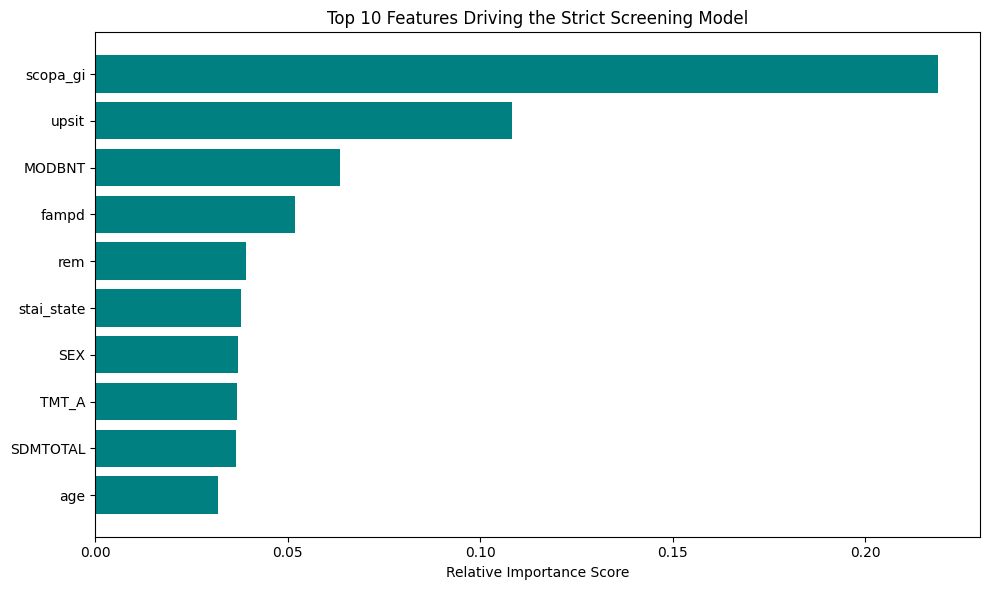

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract feature importances from your trained XGBoost model
importance_scores = model.feature_importances_
feature_names = X_strict.columns

# 2. Create a clean DataFrame and sort it
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

# 3. Print the top 15 most important features
print("--- TOP 15 FEATURE IMPORTANCES ---")
print(importance_df.head(15).to_string(index=False))

# 4. Plot the features to visually check for a sudden, massive spike
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'].head(10)[::-1], importance_df['Importance'].head(10)[::-1], color='teal')
plt.xlabel('Relative Importance Score')
plt.title('Top 10 Features Driving the Strict Screening Model')
plt.tight_layout()
plt.show()

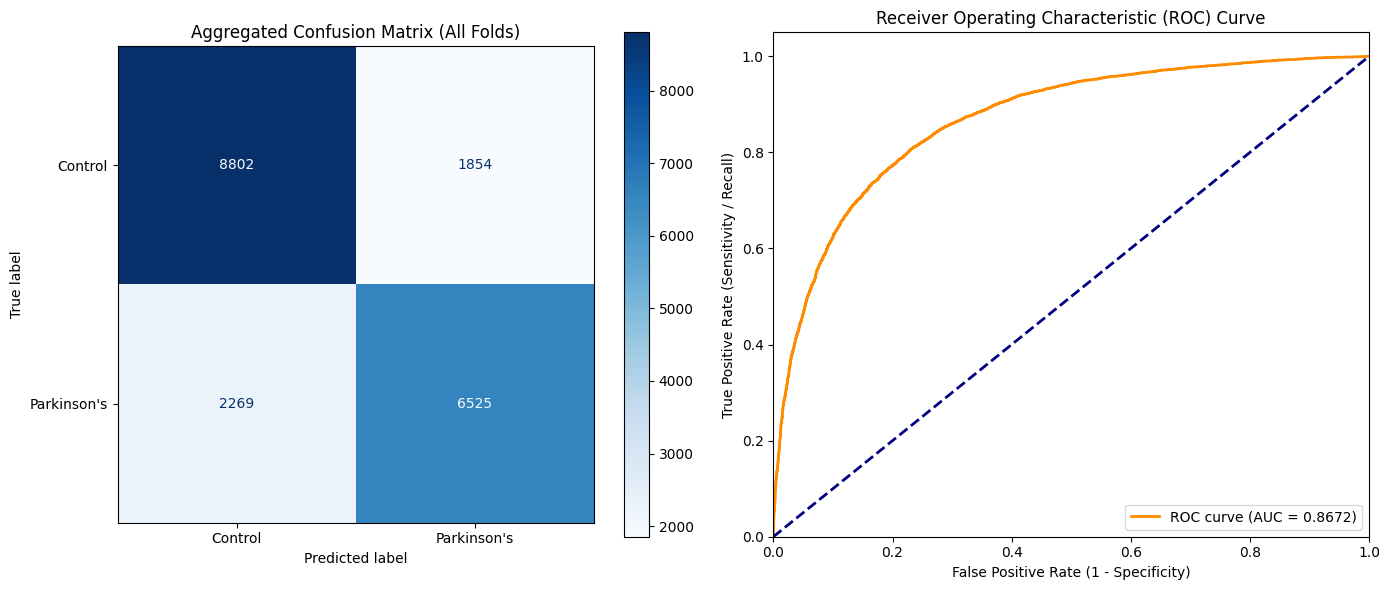

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
import xgboost as xgb

# 1. Setup lists to store true labels and predicted values across all folds
all_y_true = []
all_y_preds = []
all_y_probas = []

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

for train_idx, test_idx in skf.split(X_strict, y):
    X_train, X_test = X_strict.iloc[train_idx], X_strict.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = xgb.XGBClassifier(
        n_estimators=100, learning_rate=0.05, max_depth=5,
        enable_categorical=True, tree_method='hist', random_state=42
    )
    model.fit(X_train, y_train)

    # Store predictions for the current fold
    all_y_true.extend(y_test)
    all_y_preds.extend(model.predict(X_test))
    all_y_probas.extend(model.predict_proba(X_test)[:, 1])

# Convert lists to numpy arrays
all_y_true = np.array(all_y_true)
all_y_preds = np.array(all_y_preds)
all_y_probas = np.array(all_y_probas)

# 2. Calculate final metrics
cm = confusion_matrix(all_y_true, all_y_preds)
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_probas)
roc_auc = auc(fpr, tpr)

# 3. Plot Confusion Matrix and ROC Curve side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Control', 'Parkinson\'s'])
disp.plot(ax=ax[0], cmap='Blues', values_format='d')
ax[0].set_title('Aggregated Confusion Matrix (All Folds)')

# Plot ROC Curve
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate (1 - Specificity)')
ax[1].set_ylabel('True Positive Rate (Sensitivity / Recall)')
ax[1].set_title('Receiver Operating Characteristic (ROC) Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

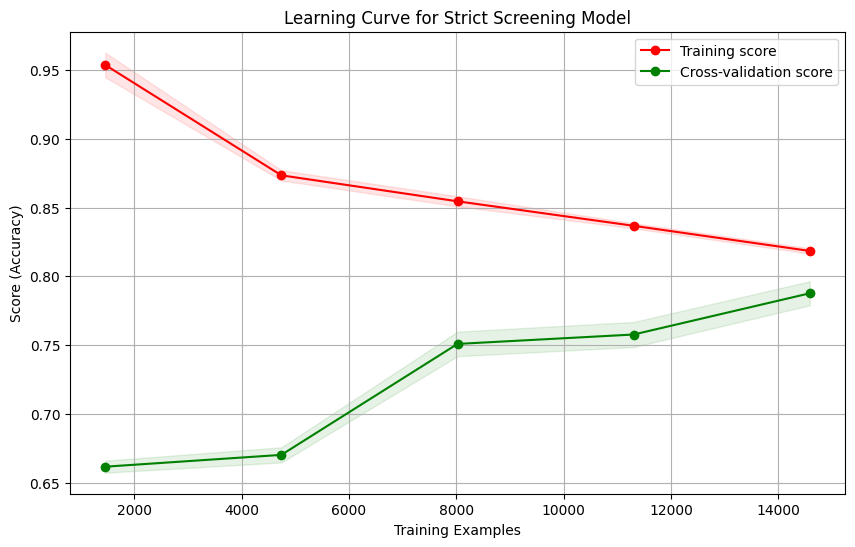

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold
import xgboost as xgb

# Initialize the XGBoost Classifier with the same parameters
estimator = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)

# Define cross-validation strategy
skf_lc = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# Calculate learning curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator,
    X_strict, # Use the X_strict features for the prodromal model
    y,
    cv=skf_lc,
    n_jobs=-1, # Use all available cores
    train_sizes=np.linspace(0.1, 1.0, 5), # Use 5 different sizes of the training set
    scoring='accuracy'
)

# Calculate mean and standard deviation for training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.title('Learning Curve for Strict Screening Model')
plt.xlabel('Training Examples')
plt.ylabel('Score (Accuracy)')
plt.grid()

plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color='r')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1,
                 color='g')
plt.plot(train_sizes, train_scores_mean, 'o-', color='r',
         label='Training score')
plt.plot(train_sizes, test_scores_mean, 'o-', color='g',
         label='Cross-validation score')

plt.legend(loc='best')
plt.show()

In [ ]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Gather features using the strict list (dropping all motor and functional metrics)
strict_leaky_features = [
    'PDAQ27', 'updrs4_score', 'upsit_pctl', 'upsit_pctl15',
    'ageonset', 'DOMSIDE', 'duration_yrs', 'agediag', 'duration',
    'updrs1_score', 'updrs2_score', 'updrs3_score', 'updrs_totscore',
    'sym_rigid', 'sym_posins', 'sym_brady', 'sym_other', 'sym_tremor',
    'NP1COG', 'NP1HALL', 'NP1DPRS', 'NP1ANXS', 'NP1APAT', 'NP1DDS', 'NP1FATG',
    'MSEADLG', 'nqol_cogns', 'nqol_comms', 'nqol_lefs', 'nqol_uefs'
]

clean_features = [col for col in target_attributes if col not in strict_leaky_features]

X_strict = df_ppmi[clean_features].copy()
if 'PRIMDIAG' in X_strict.columns:
    X_strict = X_strict.drop(columns=['PRIMDIAG'])

y = df_ppmi['PRIMDIAG'].apply(lambda x: 1 if x == 1.0 else 0)

# Convert object/string columns to 'category' type (LightGBM handles categories natively)
for col in X_strict.columns:
    if X_strict[col].dtype == 'object' or X_strict[col].dtype.name == 'category':
        X_strict[col] = X_strict[col].astype('category')

print(f"Training LightGBM on {X_strict.shape[1]} features...")

# 2. 4-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
lgb_aucs = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_strict, y), 1):
    X_train, X_test = X_strict.iloc[train_idx], X_strict.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Initialize and train LightGBM Classifier
    # (By default, LightGBM uses leaf-wise growth and handles NaNs natively)
    model_lgb = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,  # Controls leaf-wise tree complexity
        random_state=42,
        verbosity=-1    # Suppresses extra training logs
    )

    model_lgb.fit(X_train, y_train)

    # Predict classes and probabilities
    y_pred = model_lgb.predict(X_test)
    y_proba = model_lgb.predict_proba(X_test)[:, 1]

    fold_auc = roc_auc_score(y_test, y_proba)
    lgb_aucs.append(fold_auc)

    print(f"\n================ LIGHTGBM: FOLD {fold} ================")
    print(f"AUC Score: {fold_auc:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

print("\n" + "="*40)
print(f"Overall Mean LightGBM AUC: {np.mean(lgb_aucs):.4f}")
print("="*40)

Training LightGBM on 36 features...

================ LIGHTGBM: FOLD 1 ================
AUC Score: 0.8721
Confusion Matrix:
[[2217  447]
 [ 554 1645]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82      2664
           1       0.79      0.75      0.77      2199

    accuracy                           0.79      4863
   macro avg       0.79      0.79      0.79      4863
weighted avg       0.79      0.79      0.79      4863


================ LIGHTGBM: FOLD 2 ================
AUC Score: 0.8712
Confusion Matrix:
[[2236  428]
 [ 586 1613]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82      2664
           1       0.79      0.73      0.76      2199

    accuracy                           0.79      4863
   macro avg       0.79      0.79      0.79      4863
weighted avg       0.79      0.79      0.79      4863


================ LIGHTGBM: FOLD

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# 1. Gather features using the strict list (dropping all motor and functional metrics)
strict_leaky_features = [
    'PDAQ27', 'updrs4_score', 'upsit_pctl', 'upsit_pctl15',
    'ageonset', 'DOMSIDE', 'duration_yrs', 'agediag', 'duration',
    'updrs1_score', 'updrs2_score', 'updrs3_score', 'updrs_totscore',
    'sym_rigid', 'sym_posins', 'sym_brady', 'sym_other', 'sym_tremor',
    'NP1COG', 'NP1HALL', 'NP1DPRS', 'NP1ANXS', 'NP1APAT', 'NP1DDS', 'NP1FATG',
    'MSEADLG', 'nqol_cogns', 'nqol_comms', 'nqol_lefs', 'nqol_uefs'
]

clean_features = [col for col in target_attributes if col not in strict_leaky_features]

X_strict = df_ppmi[clean_features].copy()
if 'PRIMDIAG' in X_strict.columns:
    X_strict = X_strict.drop(columns=['PRIMDIAG'])

y = df_ppmi['PRIMDIAG'].apply(lambda x: 1 if x == 1.0 else 0)

# Random Forest does not natively handle categorical strings or missing values (NaNs).
# Let's quickly encode categories and impute missing data safely for this model.
X_encoded = pd.get_dummies(X_strict, drop_first=True)

# 2. 4-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
rf_aucs = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_encoded, y), 1):
    X_train, X_test = X_encoded.iloc[train_idx].copy(), X_encoded.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Impute missing values with the median (crucial for Random Forest)
    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    # Initialize and train Random Forest Classifier
    model_rf = RandomForestClassifier(
        n_estimators=200,      # Number of trees in the forest
        max_depth=8,           # Controlled depth to match your tuned structures
        random_state=42,
        n_jobs=-1              # Uses all processors for speed
    )

    model_rf.fit(X_train_imp, y_train)

    # Predict classes and probabilities
    y_pred = model_rf.predict(X_test_imp)
    y_proba = model_rf.predict_proba(X_test_imp)[:, 1]

    fold_auc = roc_auc_score(y_test, y_proba)
    rf_aucs.append(fold_auc)

    print(f"\n================ RANDOM FOREST: FOLD {fold} ================")
    print(f"AUC Score: {fold_auc:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

print("\n" + "="*40)
print(f"Overall Mean Random Forest AUC: {np.mean(rf_aucs):.4f}")
print("="*40)


================ RANDOM FOREST: FOLD 1 ================
AUC Score: 0.8412
Confusion Matrix:
[[2258  406]
 [ 717 1482]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.85      0.80      2664
           1       0.78      0.67      0.73      2199

    accuracy                           0.77      4863
   macro avg       0.77      0.76      0.76      4863
weighted avg       0.77      0.77      0.77      4863


================ RANDOM FOREST: FOLD 2 ================
AUC Score: 0.8426
Confusion Matrix:
[[2235  429]
 [ 711 1488]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.84      0.80      2664
           1       0.78      0.68      0.72      2199

    accuracy                           0.77      4863
   macro avg       0.77      0.76      0.76      4863
weighted avg       0.77      0.77      0.76      4863


================ RANDOM FOREST: FOLD 3 ================
A

In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Define a targeted hyperparameter grid
param_grid = {
    'max_depth': [4, 6, 8],               # Depth of trees to catch complex interactions
    'learning_rate': [0.01, 0.03, 0.05],  # Lower learning rates prevent aggressive overfitting
    'n_estimators': [100, 150, 200],      # Total number of boosting rounds
    'subsample': [0.7, 0.85],             # % of rows to sample per tree (introduces randomness)
    'colsample_bytree': [0.7, 0.85]       # % of features to sample per tree
}

xgb_base = xgb.XGBClassifier(enable_categorical=True, tree_method='hist', random_state=42)

# Use Stratified K-Fold to evaluate the grid
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=4,
    scoring='accuracy',
    n_jobs=-1
)

print("🔄 Tuning hyperparameters across all 36 features...")
grid_search.fit(X_strict, y)

print(f"✅ Best Parameters: {grid_search.best_params_}")
print(f"📈 Highest Tuned Accuracy: {grid_search.best_score_:.4f}")

🔄 Tuning hyperparameters across all 36 features...
✅ Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.7}
📈 Highest Tuned Accuracy: 0.7367


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Temporarily switch categories to numeric dummy variables for the imputer
X_numeric = pd.get_dummies(X_strict, drop_first=True)

# Estimate missing values based on correlations with other features
mice_imputer = IterativeImputer(max_iter=10, random_state=42)
X_imputed = mice_imputer.fit_transform(X_numeric)

# Use this X_imputed array inside your cross-validation loop!

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
X_enhanced = X_strict.copy()

# Create interactive risk proxies
# Example: High sleep score + low smell score indicates severe prodromal convergence
X_enhanced['sleep_smell_risk'] = X_enhanced['rem'] * (1 / (X_enhanced['upsit'] + 1))

# Example: Combined autonomic dysregulation index
X_enhanced['total_autonomic_burden'] = X_enhanced['scopa_gi'] + X_enhanced['scopa_ur']

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import xgboost as xgb

# Ensure any existing categorical types are preserved in the enhanced dataframe
for col in X_enhanced.columns:
    if X_enhanced[col].dtype == 'object' or X_enhanced[col].dtype.name == 'category':
        X_enhanced[col] = X_enhanced[col].astype('category')

print(f"🚀 Training tuned XGBoost with {X_enhanced.shape[1]} features (including interaction proxies)...")

# 1. Align to 5 Folds to match your friend's notebook exactly
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy, cv_precision, cv_recall, cv_f1, cv_auc = [], [], [], [], []
aggregated_cm = np.zeros((2, 2))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_enhanced, y), 1):
    X_train, X_val = X_enhanced.iloc[train_idx], X_enhanced.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Tuned hyperparameters to optimize split decisions on complex interactions
    model = xgb.XGBClassifier(
        n_estimators=150,
        learning_rate=0.03,
        max_depth=6,              # Allowed slightly deeper trees to capture the new combinations
        subsample=0.8,            # Introduce row sampling
        colsample_bytree=0.8,     # Introduce feature sampling
        enable_categorical=True,
        tree_method='hist',
        random_state=42
    )

    model.fit(X_train, y_train)

    # Evaluation
    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)[:, 1]

    cv_accuracy.append(accuracy_score(y_val, preds))
    cv_precision.append(precision_score(y_val, preds))
    cv_recall.append(recall_score(y_val, preds))
    cv_f1.append(f1_score(y_val, preds))
    cv_auc.append(roc_auc_score(y_val, probs))
    aggregated_cm += confusion_matrix(y_val, preds)

    print(f"Fold {fold} | Accuracy: {cv_accuracy[-1]:.4f} | AUC: {cv_auc[-1]:.4f}")

# 2. Final Performance Summary
print("\n" + "="*50)
print("     💥 ENHANCED XGBOOST SCREENING PERFORMANCE 💥")
print("="*50)
print(f"🎯 Mean Stratified Accuracy : {np.mean(cv_accuracy):.4f}")
print(f"🎯 Mean Clinical Precision  : {np.mean(cv_precision):.4f}")
print(f"🎯 Mean Recall (Sensitivity): {np.mean(cv_recall):.4f}")
print(f"🎯 Mean Balanced F1-Score   : {np.mean(cv_f1):.4f}")
print(f"🎯 Mean Area Under ROC (AUC): {np.mean(cv_auc):.4f}")
print("="*50)
print("Aggregated Confusion Matrix:")
print(aggregated_cm.astype(int))
print("="*50)

# 3. Quick Check: Did the model actually value your new features?
importance_scores = model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X_enhanced.columns,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

print("\n📈 How much the model relied on your engineered variables:")
print(importance_df[importance_df['Feature'].isin(['sleep_smell_risk', 'total_autonomic_burden'])].to_string(index=False))

🚀 Training tuned XGBoost with 38 features (including interaction proxies)...
Fold 1 | Accuracy: 0.8080 | AUC: 0.8838
Fold 2 | Accuracy: 0.7943 | AUC: 0.8746
Fold 3 | Accuracy: 0.8082 | AUC: 0.8861
Fold 4 | Accuracy: 0.8041 | AUC: 0.8768
Fold 5 | Accuracy: 0.7835 | AUC: 0.8658

     💥 ENHANCED XGBOOST SCREENING PERFORMANCE 💥
🎯 Mean Stratified Accuracy : 0.7996
🎯 Mean Clinical Precision  : 0.7876
🎯 Mean Recall (Sensitivity): 0.7631
🎯 Mean Balanced F1-Score   : 0.7751
🎯 Mean Area Under ROC (AUC): 0.8774
Aggregated Confusion Matrix:
[[8842 1814]
 [2083 6711]]

📈 How much the model relied on your engineered variables:
               Feature  Importance
      sleep_smell_risk    0.044969
total_autonomic_burden    0.022365


In [ ]:
import numpy as np

print(f"Mean ROC AUC across folds: {np.mean(rf_aucs):.4f}")
print(f"Mean Recall across folds: {np.mean(cv_recall):.4f}")

Mean ROC AUC across folds: 0.8398
Mean Recall across folds: 0.7631


The Mean ROC AUC across the folds is **0.8398**.
The Mean Recall across the folds is **0.7631**.

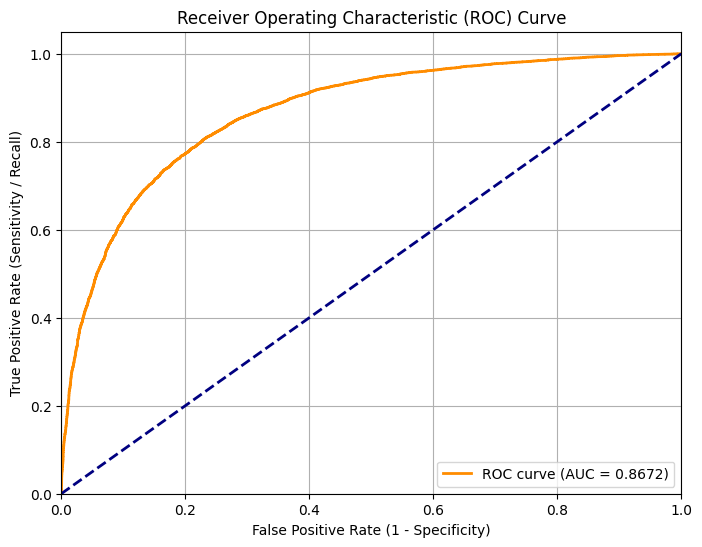

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming 'all_y_true' and 'all_y_probas' are available from previous cells
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_probas)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

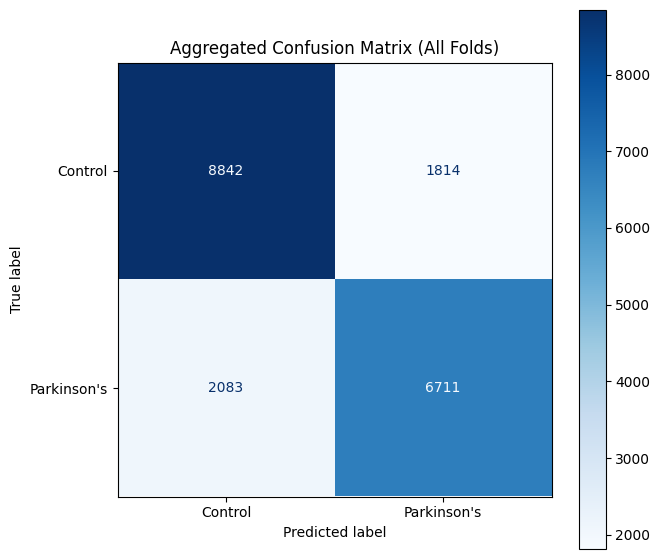

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# Assuming 'aggregated_cm' is available from previous cells (Fe50aooDaSLv)
# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(7, 7))

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=aggregated_cm.astype(int), display_labels=['Control', 'Parkinson\'s'])
disp.plot(ax=ax, cmap='Blues', values_format='d')

# Set title
ax.set_title('Aggregated Confusion Matrix (All Folds)')
plt.show()

### Enhanced XGBoost Screening Model Performance

- **Mean Stratified Accuracy:** 0.7996
- **Mean Clinical Precision:** 0.7876
- **Mean Recall (Sensitivity):** 0.7631
- **Mean Balanced F1-Score:** 0.7751
- **Mean Area Under ROC (AUC):** 0.8774